# Data Visualization for Logfile

This project will visualize and bring insights from our processed parquet files, created with the source as our Apache logs.

### Imports and data reads

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

Read our parquet file

In [9]:
df = pd.read_parquet("files/Apache.parquet")
df.head()
df_polars = pl.from_pandas(df)

Querying our volume of alerts with type categorization

In [92]:
query="""
SELECT
    CONCAT(EXTRACT('year', date), '-', EXTRACT('month', date)) as year_month,
    type,
    count(type) as type_count,
FROM self
GROUP BY year_month, type
ORDER BY year_month
"""

result_df = df_polars.sql(query)


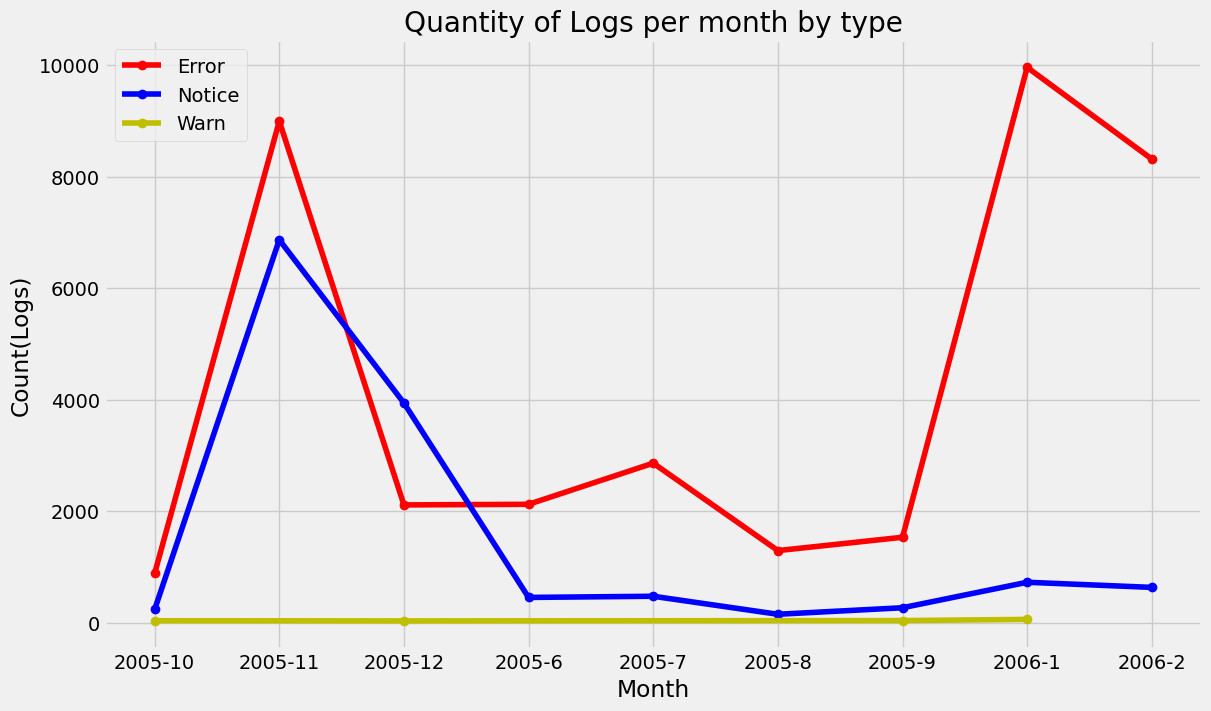

In [91]:

plt.style.use('fivethirtyeight')
err_df=result_df.filter(pl.col("type")=="error")
not_df=result_df.filter(pl.col("type")=="notice")
warn_df=result_df.filter(pl.col("type")=="warn")
plt.figure(figsize=(12, 7), layout='constrained')
plt.plot(err_df['year_month'], err_df["type_count"], marker='o', label='Error', c='r')
plt.plot(not_df['year_month'], not_df["type_count"], marker='o', label='Notice', c='b')
plt.plot(warn_df['year_month'], warn_df["type_count"], marker='o', label='Warn', c='y')
plt.xlabel('Month')
plt.ylabel('Count(Logs)')
plt.title('Quantity of Logs per month by type')
plt.legend()
plt.show()

In [85]:
query="""
SELECT
    client,
    type,
    count(type) as type_count,
    FROM self
    GROUP BY client, type
    ORDER BY type_count DESC
    LIMIT 15
"""

result_df = df_polars.sql(query)
print(result_df.filter(pl.col("type")=="error"))


shape: (13, 3)
┌─────────────────┬───────┬────────────┐
│ client          ┆ type  ┆ type_count │
│ ---             ┆ ---   ┆ ---        │
│ str             ┆ str   ┆ u32        │
╞═════════════════╪═══════╪════════════╡
│                 ┆ error ┆ 6966       │
│ 218.144.240.75  ┆ error ┆ 1002       │
│ 210.245.233.251 ┆ error ┆ 624        │
│ 211.99.203.228  ┆ error ┆ 440        │
│ 80.55.121.106   ┆ error ┆ 322        │
│ …               ┆ …     ┆ …          │
│ 64.6.73.199     ┆ error ┆ 276        │
│ 81.114.87.11    ┆ error ┆ 274        │
│ 65.19.195.6     ┆ error ┆ 262        │
│ 80.55.248.206   ┆ error ┆ 258        │
│ 163.117.142.142 ┆ error ┆ 253        │
└─────────────────┴───────┴────────────┘
